In [44]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification
import pandas as pd 

In [45]:
x,y = make_classification(n_samples=1000, n_features= 10,  shuffle= True, n_classes=2, random_state=42)
x.shape, y.shape

((1000, 10), (1000,))

In [46]:
df = pd.concat([pd.DataFrame(x), pd.DataFrame(y,columns=['Label'])],axis=1)
df.head()

,0,1,2,3,4,5,6,7,8,9,Label
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274,0
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470,1
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376,1
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039,0
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224,1


In [47]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)
print(list[x_train.shape,x_test.shape,y_train.shape,y_test.shape])

list[(800, 10), (200, 10), (800,), (200,)]


In [48]:
# AdaBoostClassifier(n_estimators=100, learning_rate=1,algorithm="SAMME.R")

In [49]:
params = { 'n_estimators': [50,100,150,200,250],
           'learning_rate': [0.2,0.5,0.7,1],
           'algorithm': ['SAMME']
          }

clf = GridSearchCV(AdaBoostClassifier(random_state=42),params,n_jobs=-1,cv = 5, scoring='roc_auc')

clf.fit(x_train,y_train)


print("Best classifier parameter  for Adaboost is ",clf.best_estimator_)
print("Best score   for Adaboost is ",clf.best_score_)
print("Best parameter   for Adaboost is ",clf.best_params_)

d:\Coding\deep-learning-pytorch\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best classifier parameter  for Adaboost is  AdaBoostClassifier(algorithm='SAMME', learning_rate=0.7, n_estimators=250,
                   random_state=42)
Best score   for Adaboost is  0.9465388221338852
Best parameter   for Adaboost is  {'algorithm': 'SAMME', 'learning_rate': 0.7, 'n_estimators': 250}


In [50]:
para_df = pd.DataFrame(clf.cv_results_)
para_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_learning_rate,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.423729,0.081943,0.056704,0.037289,SAMME,0.2,50,"{'algorithm': 'SAMME', 'learning_rate': 0.2, '...",0.943168,0.934959,0.966776,0.955250,0.912377,0.942506,0.018529,15
1,0.979535,0.246739,0.071185,0.021485,SAMME,0.2,100,"{'algorithm': 'SAMME', 'learning_rate': 0.2, '...",0.945044,0.934959,0.968340,0.955250,0.911829,0.943084,0.019145,14
2,1.296203,0.234292,0.063684,0.019403,SAMME,0.2,150,"{'algorithm': 'SAMME', 'learning_rate': 0.2, '...",0.943871,0.941057,0.968965,0.956032,0.912064,0.944398,0.018952,11
3,1.504056,0.147158,0.101118,0.023707,SAMME,0.2,200,"{'algorithm': 'SAMME', 'learning_rate': 0.2, '...",0.943558,0.943324,0.968965,0.955719,0.907683,0.943850,0.020396,13
4,1.706351,0.225050,0.098257,0.012608,SAMME,0.2,250,"{'algorithm': 'SAMME', 'learning_rate': 0.2, '...",0.943168,0.943480,0.970216,0.957362,0.915350,0.945915,0.018272,6


In [66]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt


In [73]:
feature_idx = [0, 1]

filler_values = {
    i: x_train.iloc[:, i].mean()
    for i in range(x_train.shape[1])
}

# Remove the two features being plotted
del filler_values[0]
del filler_values[8]

In [74]:
import numpy as np

tuned_clf = AdaBoostClassifier(learning_rate=0.7, n_estimators=250)
tuned_clf.fit(x_train,y_train)
pred = tuned_clf.predict(x_train)

print(np.unique(pred, return_counts=True))

important_fea = tuned_clf.feature_importances_

for i in enumerate(important_fea):
    print(i)

(array([0, 1]), array([413, 387]))
(0, np.float64(0.242186779376896))
(1, np.float64(0.017566730397738258))
(2, np.float64(0.10630649614567136))
(3, np.float64(0.009220047180665485))
(4, np.float64(0.08276042866043595))
(5, np.float64(0.03914956590525515))
(6, np.float64(0.1687246885014197))
(7, np.float64(0.025178527568178777))
(8, np.float64(0.2701392028925726))
(9, np.float64(0.038767533371166424))


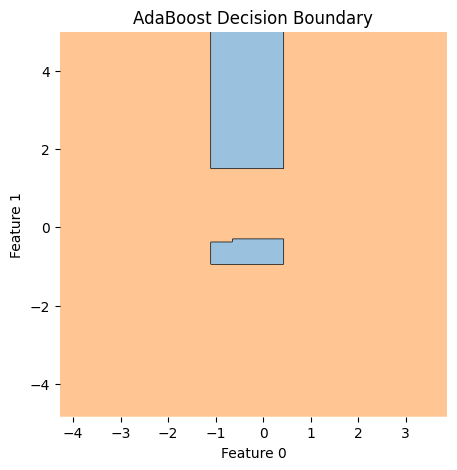

In [76]:
plt.figure(figsize=(5, 5))

plot_decision_regions(
    X=x_train.to_numpy(),
    y=y_train.to_numpy(),
    clf=tuned_clf,
    feature_index=[0, 8],
    filler_feature_values=filler_values
)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("AdaBoost Decision Boundary")
plt.show()

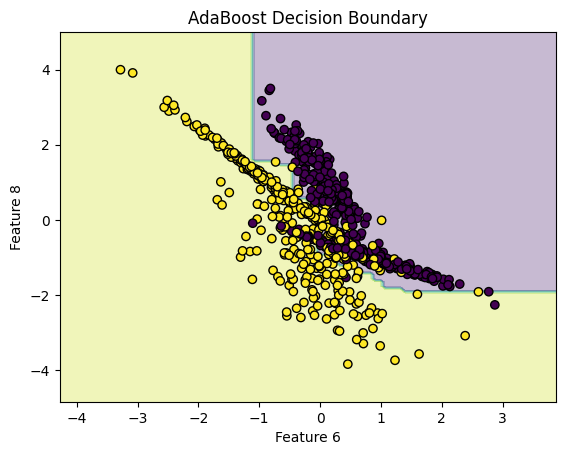

In [78]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

X = x_train.iloc[:, [0, 8]]
y = y_train

model_2d = AdaBoostClassifier(
    learning_rate=0.7,
    n_estimators=250
)

model_2d.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
    model_2d,
    X,
    response_method="predict",
    alpha=0.3
)

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="black")
plt.xlabel("Feature 6")
plt.ylabel("Feature 8")
plt.title("AdaBoost Decision Boundary")
plt.show()